In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import beta as beta_dist
from transformers import AutoTokenizer, AutoModel
import torch
import pickle
import time
import warnings
warnings.filterwarnings("ignore")

/Users/leojin/miniconda3/envs/cs763-amp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")
test_sequences = np.load("../data/test_sequences.npy", allow_pickle=True)
clf = joblib.load("../models/lr_classifier.pkl")
print(f"Test set: {len(X_test)} sequences")

Test set: 984 sequences


In [3]:
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm2 = AutoModel.from_pretrained(MODEL_NAME)
esm2.eval()

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 320, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
    (position_embeddings): Embedding(1026, 320, padding_idx=1)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-5): 6 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=320, out_features=320, bias=True)
            (key): Linear(in_features=320, out_features=320, bias=True)
            (value): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
    

In [11]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def randomize_sequence(seq, p):
    arr = np.array(list(seq))
    mask = np.random.random(len(arr)) < p
    arr[mask] = np.random.choice(AMINO_ACIDS, size=mask.sum())
    return "".join(arr)

def get_embeddings(sequences, tokenizer, model, batch_size=32):
    all_embs = []
    for i in range(0, len(sequences), batch_size):
        batch  = sequences[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt",
                           padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            out = model(**inputs)
        mask   = inputs["attention_mask"].unsqueeze(-1).float()  # (B, L, 1)
        summed = (out.last_hidden_state * mask).sum(dim=1)        # (B, D)
        counts = mask.sum(dim=1).clamp(min=1e-9)                  # (B, 1)
        all_embs.append((summed / counts).numpy())
    return np.vstack(all_embs)

def clopper_pearson_lower(n_success, n_total, alpha=0.001):
    """
    One-sided Clopper–Pearson lower bound on the true success probability.
    """
    if n_success == 0:
        return 0.0
    return float(beta_dist.ppf(alpha, n_success, n_total - n_success + 1))

def certify_sequence(seq, clf, tokenizer, model, p, T=1000, alpha=0.001):
    """
    Run discrete randomized smoothing on one sequence.

    Parameters
    ----------
    p     : per-position randomization probability
    T     : number of noisy samples
    alpha : one-sided significance level for Clopper–Pearson (default 0.1%)

    Returns
    -------
    prediction : 1 (AMP), 0 (non-AMP), or -1 (abstain — neither class
                 certified with enough confidence)
    radius     : certified Hamming-ball radius R (0 when abstaining)
    p_lower    : the Clopper–Pearson lower bound used for certification
    """
    noisy_seqs = [randomize_sequence(seq, p) for _ in range(T)]
    embs = get_embeddings(noisy_seqs, tokenizer, model)
    preds = clf.predict(embs)
    n_A = int(preds.sum())      # number of noisy copies predicting AMP
    n_B = T - n_A               # number predicting non-AMP

    p_A_lower = clopper_pearson_lower(n_A, T, alpha)
    p_B_lower = clopper_pearson_lower(n_B, T, alpha)

    if p_A_lower > 0.5:
        R = int(np.floor(np.log(p_A_lower) / np.log(1.0 - p)))
        return 1, R, p_A_lower
    elif p_B_lower > 0.5:
        R = int(np.floor(np.log(p_B_lower) / np.log(1.0 - p)))
        return 0, R, p_B_lower
    else:
        return -1, 0, max(p_A_lower, p_B_lower)

In [12]:
P_VALUES = [0.05, 0.10, 0.15]
T = 1000
MAX_SEQS = 150

eval_seqs   = test_sequences
eval_labels = y_test
print(f"Evaluating {len(eval_seqs)} sequences  |  T={T}  |  p ∈ {P_VALUES}")


Evaluating 984 sequences  |  T=1000  |  p ∈ [0.05, 0.1, 0.15]


In [13]:
all_results = {}   # p → pd.DataFrame of per-sequence results
for p in P_VALUES:
    print(f'p-level: {p}')
    records = []
    t0 = time.time()
    for i, (seq, true_label) in enumerate(zip(eval_seqs, eval_labels)):
        pred, R, p_lower = certify_sequence(
            seq, clf, tokenizer, esm2, p=p, T=T)
        records.append({"true_label" : int(true_label),
                         "pred" : pred,
                         "radius" : R,
                         "p_lower" : p_lower})
        if (i + 1) % 25 == 0:
            print(f"{i+1}/{len(eval_seqs)}  elapsed={time.time()-t0:.0f}s")

    all_results[p] = pd.DataFrame(records)
    df_p = all_results[p]
    coverage = (df_p["pred"] != -1).mean()
    print(f"coverage = {coverage*100:.1f}%")



p-level: 0.05
25/984  elapsed=78s
50/984  elapsed=149s
75/984  elapsed=237s
100/984  elapsed=318s
125/984  elapsed=404s
150/984  elapsed=489s
175/984  elapsed=571s
200/984  elapsed=656s
225/984  elapsed=747s
250/984  elapsed=827s
275/984  elapsed=912s
300/984  elapsed=990s
325/984  elapsed=1078s
350/984  elapsed=1162s
375/984  elapsed=1252s
400/984  elapsed=1346s
425/984  elapsed=1428s
450/984  elapsed=1515s
475/984  elapsed=1601s
500/984  elapsed=1695s
525/984  elapsed=1790s
550/984  elapsed=1889s
575/984  elapsed=1981s
600/984  elapsed=2059s
625/984  elapsed=2150s
650/984  elapsed=2245s
675/984  elapsed=2335s
700/984  elapsed=2419s
725/984  elapsed=2509s
750/984  elapsed=2589s
775/984  elapsed=2676s
800/984  elapsed=2759s
825/984  elapsed=2846s
850/984  elapsed=2940s
875/984  elapsed=3033s
900/984  elapsed=3131s
925/984  elapsed=3213s
950/984  elapsed=3292s
975/984  elapsed=3377s
coverage = 98.9%
p-level: 0.1
25/984  elapsed=83s
50/984  elapsed=158s
75/984  elapsed=249s
100/984  elap

In [14]:
certified = df_p[df_p["pred"] != -1]
certified

,true_label,pred,radius,p_lower
0,1,1,0,0.940763
1,0,0,3,0.534893
2,0,0,0,0.939536
3,0,0,1,0.766991
4,0,0,0,0.985285
...,...,...,...,...
979,1,1,1,0.845183
980,1,1,1,0.845183
981,0,0,0,0.993116
982,1,1,0,0.883268


In [15]:
rows = []
for p, df_p in all_results.items():
    certified = df_p[df_p["pred"] != -1]
    clean_acc   = (certified["pred"] == certified["true_label"]).mean()
    mean_radius = certified["radius"].mean()
    coverage = len(certified) / len(df_p)

    for R_thresh in [1, 2, 3]:
        cert_correct = df_p[
            (df_p["pred"]   == df_p["true_label"]) &
            (df_p["radius"] >= R_thresh)
        ]
        rows.append({
            "p"             : p,
            "R_threshold"   : R_thresh,
            "certified_acc" : len(cert_correct) / len(df_p),
            "clean_acc"     : clean_acc,
            "coverage"      : coverage,
            "mean_radius"   : mean_radius,
        })

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("../results/tables/04_certified_accuracy.csv", index=False)


   p  R_threshold  certified_acc  clean_acc  coverage  mean_radius
0.05            1       0.192073   0.829394  0.988821     1.271326
0.05            2       0.131098   0.829394  0.988821     1.271326
0.05            3       0.102642   0.829394  0.988821     1.271326
0.10            1       0.210366   0.836478  0.969512     0.800839
0.10            2       0.120935   0.836478  0.969512     0.800839
0.10            3       0.085366   0.836478  0.969512     0.800839
0.15            1       0.229675   0.813736  0.976626     0.671176
0.15            2       0.101626   0.813736  0.976626     0.671176
0.15            3       0.053862   0.813736  0.976626     0.671176


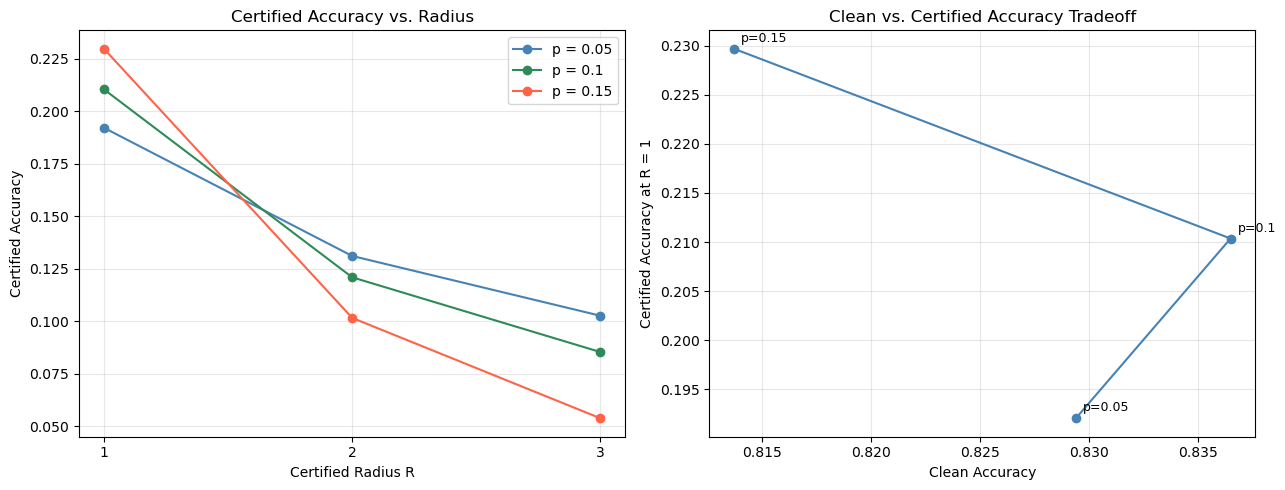

In [16]:
colors = ["steelblue", "seagreen", "tomato"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: certified accuracy at R = 1, 2, 3 per noise level p
for p, color in zip(P_VALUES, colors):
    sub = df_metrics[df_metrics["p"] == p].sort_values("R_threshold")
    axes[0].plot(sub["R_threshold"], sub["certified_acc"],
                 marker="o", label=f"p = {p}", color=color)
axes[0].set_xlabel("Certified Radius R")
axes[0].set_ylabel("Certified Accuracy")
axes[0].set_title("Certified Accuracy vs. Radius")
axes[0].set_xticks([1, 2, 3])
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: clean accuracy vs. certified accuracy at R = 1 (noise-level tradeoff)
sub_r1 = df_metrics[df_metrics["R_threshold"] == 1].sort_values("p")
axes[1].plot(sub_r1["clean_acc"], sub_r1["certified_acc"],
             marker="o", color="steelblue")
for _, row in sub_r1.iterrows():
    axes[1].annotate(f"p={row['p']}",
                     xy=(row["clean_acc"], row["certified_acc"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[1].set_xlabel("Clean Accuracy")
axes[1].set_ylabel("Certified Accuracy at R = 1")
axes[1].set_title("Clean vs. Certified Accuracy Tradeoff")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/04_certified_defense.png", dpi=150)
plt.show()


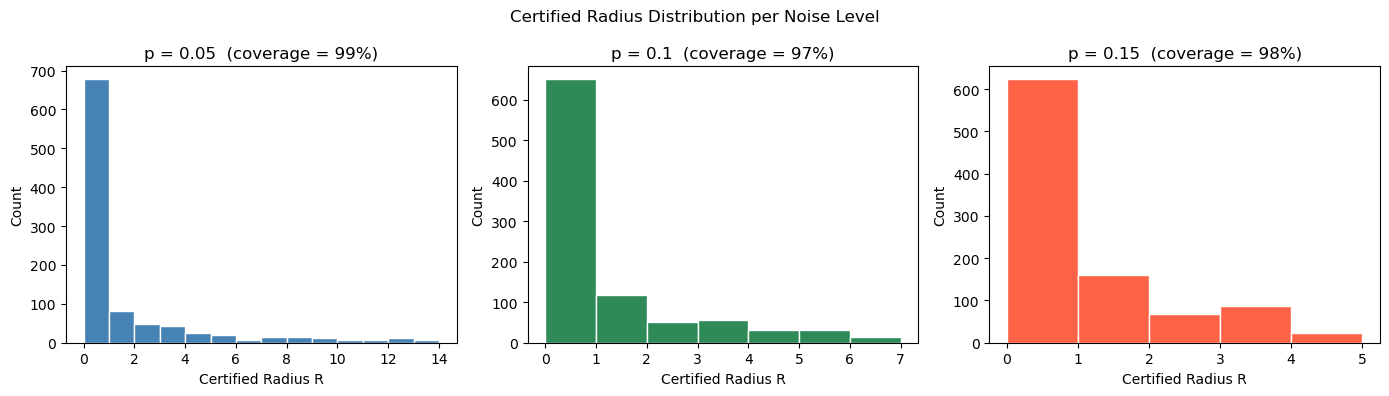

In [17]:
fig, axes = plt.subplots(1, len(P_VALUES), figsize=(14, 4))

for ax, (p, color) in zip(axes, zip(P_VALUES, colors)):
    df_p = all_results[p]
    cert = df_p[df_p["pred"] != -1]
    coverage_pct = len(cert) / len(df_p) * 100

    if len(cert) > 0 and cert["radius"].max() > 0:
        bins = range(0, int(cert["radius"].max()) + 2)
        ax.hist(cert["radius"], bins=bins, color=color, edgecolor="white")
    else:
        ax.text(0.5, 0.5, "No certified sequences",
                ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"p = {p}  (coverage = {coverage_pct:.0f}%)")
    ax.set_xlabel("Certified Radius R")
    ax.set_ylabel("Count")

plt.suptitle("Certified Radius Distribution per Noise Level")
plt.tight_layout()
plt.savefig("../results/figures/04_radius_distribution.png", dpi=150)
plt.show()


In [18]:
with open("../data/smoothing_results.pkl", "wb") as f:
    pickle.dump(all_results, f)
